# 02 Main Analysis

Cycle 3 main analysis: **Gender and Current Alcohol Use**

This notebook uses the cleaned dataset from `01_data_cleaning.ipynb`.

Main task:
- Compare current alcohol use proportion between male and female students
- Make summary table
- Run two-proportion z-test
- Compute 95% confidence interval for difference in proportions
- Export figures and tables

## 1. Import libraries and set paths

In [25]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

# statsmodels is used for two-proportion z-test and confidence interval
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep

project_dir = Path("..")

cleaned_data_path = project_dir / "data" / "processed" / "cycle3_cleaned_main.csv"

figures_dir = project_dir / "outputs" / "figures"
tables_dir = project_dir / "outputs" / "tables"
summary_dir = project_dir / "outputs" / "summary"

figures_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)
summary_dir.mkdir(parents=True, exist_ok=True)

print("Paths are ready.")

Paths are ready.


## 2. Load cleaned data

In [26]:
df = pd.read_csv(cleaned_data_path)

print("Cleaned data shape:", df.shape)
display(df.head())

print("\nSex group counts:")
display(df["sex_group"].value_counts())

print("\nCurrent alcohol use counts:")
display(df["current_alcohol_use"].value_counts())

Cleaned data shape: (12659, 2)


,sex_group,current_alcohol_use
0,Female,0
1,Female,0
2,Female,0
3,Female,0
4,Female,0



Sex group counts:


sex_group
Female    6425
Male      6234
Name: count, dtype: int64


Current alcohol use counts:


current_alcohol_use
0    6942
1    5717
Name: count, dtype: int64

## 3. Create summary table

`current_alcohol_use` is binary:

- `0` = no current alcohol use
- `1` = current alcohol use

The mean of a 0/1 variable is the **proportion** of 1s.

In [27]:
summary_table = (
    df
    .groupby("sex_group")
    .agg(
        sample_size=("current_alcohol_use", "count"),
        alcohol_users=("current_alcohol_use", "sum"),
        alcohol_use_proportion=("current_alcohol_use", "mean")
    )
    .reset_index()
)

summary_table["alcohol_use_percent"] = summary_table["alcohol_use_proportion"] * 100

# Put Female first, Male second
summary_table["sex_group"] = pd.Categorical(
    summary_table["sex_group"],
    categories=["Female", "Male"],
    ordered=True
)
summary_table = summary_table.sort_values("sex_group").reset_index(drop=True)

display(summary_table)

summary_table.to_csv(tables_dir / "summary_table_alcohol_by_gender.csv", index=False)
print("Saved:", tables_dir / "summary_table_alcohol_by_gender.csv")

,sex_group,sample_size,alcohol_users,alcohol_use_proportion,alcohol_use_percent
0,Female,6425,2864,0.445759,44.575875
1,Male,6234,2853,0.457652,45.765159


Saved: ..\outputs\tables\summary_table_alcohol_by_gender.csv


## 4. Bar chart: Current alcohol use by sex

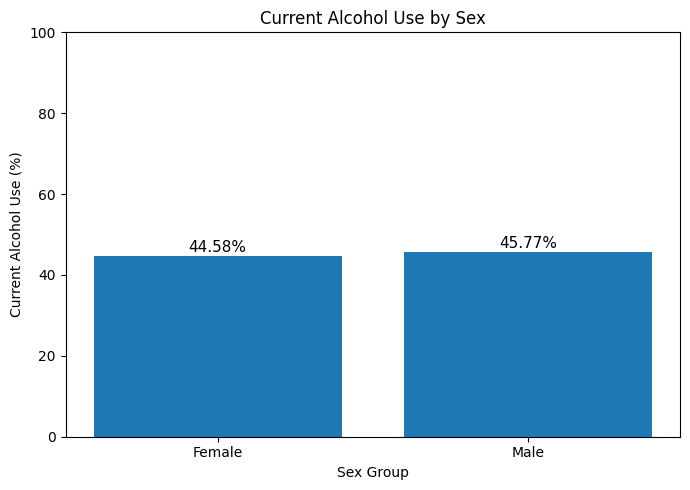

Saved: ..\outputs\figures\bar_chart_alcohol_by_gender.png


In [28]:
plt.figure(figsize=(7, 5))

bars = plt.bar(
    summary_table["sex_group"].astype(str),
    summary_table["alcohol_use_percent"]
)

plt.xlabel("Sex Group")
plt.ylabel("Current Alcohol Use (%)")
plt.title("Current Alcohol Use by Sex")
plt.ylim(0, 100)

for i, value in enumerate(summary_table["alcohol_use_percent"]):
    plt.text(i, value + 1, f"{value:.2f}%", ha="center", fontsize=11)

plt.tight_layout()
plt.savefig(figures_dir / "bar_chart_alcohol_by_gender.png", dpi=300)
plt.show()

print("Saved:", figures_dir / "bar_chart_alcohol_by_gender.png")

## 5. Two-proportion z-test

Research question:

> Is the proportion of current alcohol use different between male and female students?

Hypotheses:

\[
H_0: p_{male} = p_{female}
\]

\[
H_1: p_{male} \ne p_{female}
\]

Difference is defined as:

\[
p_{male} - p_{female}
\]

In [29]:
group_summary = summary_table.set_index("sex_group")

female_success = int(group_summary.loc["Female", "alcohol_users"])
female_n = int(group_summary.loc["Female", "sample_size"])
female_prop = float(group_summary.loc["Female", "alcohol_use_proportion"])

male_success = int(group_summary.loc["Male", "alcohol_users"])
male_n = int(group_summary.loc["Male", "sample_size"])
male_prop = float(group_summary.loc["Male", "alcohol_use_proportion"])

difference = male_prop - female_prop

print("Female:")
print("  n =", female_n)
print("  current alcohol users =", female_success)
print("  proportion =", female_prop)
print("  percent =", female_prop * 100)

print("\nMale:")
print("  n =", male_n)
print("  current alcohol users =", male_success)
print("  proportion =", male_prop)
print("  percent =", male_prop * 100)

print("\nDifference in proportions (Male - Female) =", difference)
print("Difference in percentage points =", difference * 100)

Female:
  n = 6425
  current alcohol users = 2864
  proportion = 0.4457587548638132
  percent = 44.57587548638132

Male:
  n = 6234
  current alcohol users = 2853
  proportion = 0.45765158806544753
  percent = 45.765158806544754

Difference in proportions (Male - Female) = 0.011892833201634312
Difference in percentage points = 1.1892833201634312


In [30]:
# Two-proportion z-test
# count and nobs order determines the sign of z.
# We use [Male, Female], so the difference is Male - Female.

count = np.array([male_success, female_success])
nobs = np.array([male_n, female_n])

z_stat, p_value = proportions_ztest(
    count=count,
    nobs=nobs,
    alternative="two-sided"
)

print("z statistic:", z_stat)
print("p-value:", p_value)

z statistic: 1.344245502225726
p-value: 0.17886901204413974


## 6. 95% confidence interval for difference in proportions

The interval estimates:

\[
p_{male} - p_{female}
\]

If the interval includes 0, it means 0 is a plausible value for the true difference.

In [31]:
ci_low, ci_high = confint_proportions_2indep(
    count1=male_success,
    nobs1=male_n,
    count2=female_success,
    nobs2=female_n,
    method="wald"
)

print("95% CI for Male - Female:")
print("Lower:", ci_low)
print("Upper:", ci_high)
print("In percentage points:", ci_low * 100, "to", ci_high * 100)

95% CI for Male - Female:
Lower: -0.005446764877567067
Upper: 0.02923243128083569
In percentage points: -0.5446764877567067 to 2.923243128083569


## 7. CI plot

This plot shows the estimated difference and its 95% confidence interval.

## 8. Effect size

For this project, the main effect size is the difference in proportions:

\[
\hat{p}_{male} - \hat{p}_{female}
\]

This is reported in **percentage points**.

In [32]:
effect_size_table = pd.DataFrame({
    "Measure": [
        "Female alcohol use proportion",
        "Male alcohol use proportion",
        "Difference in proportions (Male - Female)",
        "Difference in percentage points",
        "Relative risk (Male / Female)"
    ],
    "Value": [
        female_prop,
        male_prop,
        difference,
        difference * 100,
        male_prop / female_prop
    ]
})

display(effect_size_table)

effect_size_table.to_csv(tables_dir / "effect_size_table_alcohol_by_gender.csv", index=False)
print("Saved:", tables_dir / "effect_size_table_alcohol_by_gender.csv")

,Measure,Value
0,Female alcohol use proportion,0.445759
1,Male alcohol use proportion,0.457652
2,Difference in proportions (Male - Female),0.011893
3,Difference in percentage points,1.189283
4,Relative risk (Male / Female),1.026680


Saved: ..\outputs\tables\effect_size_table_alcohol_by_gender.csv


## 9. Save inference table and final summary

In [33]:
inference_table = pd.DataFrame({
    "Statistic": [
        "Female sample size",
        "Female current alcohol users",
        "Female alcohol use proportion",
        "Female alcohol use percent",
        "Male sample size",
        "Male current alcohol users",
        "Male alcohol use proportion",
        "Male alcohol use percent",
        "Difference in proportions (Male - Female)",
        "Difference in percentage points",
        "95% CI lower bound",
        "95% CI upper bound",
        "95% CI lower bound percentage points",
        "95% CI upper bound percentage points",
        "z statistic",
        "p-value"
    ],
    "Value": [
        female_n,
        female_success,
        female_prop,
        female_prop * 100,
        male_n,
        male_success,
        male_prop,
        male_prop * 100,
        difference,
        difference * 100,
        ci_low,
        ci_high,
        ci_low * 100,
        ci_high * 100,
        z_stat,
        p_value
    ]
})

display(inference_table)

inference_table.to_csv(tables_dir / "inference_table_alcohol_by_gender.csv", index=False)
print("Saved:", tables_dir / "inference_table_alcohol_by_gender.csv")

,Statistic,Value
0,Female sample size,6425.000000
1,Female current alcohol users,2864.000000
2,Female alcohol use proportion,0.445759
3,Female alcohol use percent,44.575875
4,Male sample size,6234.000000
5,Male current alcohol users,2853.000000
6,Male alcohol use proportion,0.457652
7,Male alcohol use percent,45.765159
8,Difference in proportions (Male - Female),0.011893
9,Difference in percentage points,1.189283


Saved: ..\outputs\tables\inference_table_alcohol_by_gender.csv


In [34]:
alpha = 0.05

if p_value < alpha:
    decision = "reject H0"
    conclusion = (
        "There is sufficient statistical evidence to conclude that "
        "the proportion of current alcohol use differs between male and female students."
    )
else:
    decision = "fail to reject H0"
    conclusion = (
        "There is not enough statistical evidence to conclude that "
        "the proportion of current alcohol use differs between male and female students."
    )

final_summary = f'''
# Cycle 3 Main Analysis Summary

## Research Question

Is the proportion of current alcohol use different between male and female students?

## Variables

- Group variable: `WhatIsYourSex`
- Response variable: `CurrentAlcoholUse`
- Recoding: `0 = no current alcohol use`, `1 = current alcohol use`

## Method

Because the response variable is binary, a two-proportion z-test was used.

## Key Results

- Female: n = {female_n}, current alcohol use = {female_prop * 100:.2f}%
- Male: n = {male_n}, current alcohol use = {male_prop * 100:.2f}%
- Difference (Male - Female) = {difference * 100:.2f} percentage points
- 95% CI = {ci_low * 100:.2f}% to {ci_high * 100:.2f}%
- z = {z_stat:.4f}
- p-value = {p_value:.4f}

## Decision

At alpha = {alpha}, we {decision}.

## Conclusion

{conclusion}

## Practical Interpretation

The observed sample difference is {difference * 100:.2f} percentage points. This is a small difference and should be interpreted carefully, especially because the data are observational survey data.
'''

(summary_dir / "final_summary.md").write_text(final_summary, encoding="utf-8")

print(final_summary)
print("Saved:", summary_dir / "final_summary.md")


# Cycle 3 Main Analysis Summary

## Research Question

Is the proportion of current alcohol use different between male and female students?

## Variables

- Group variable: `WhatIsYourSex`
- Response variable: `CurrentAlcoholUse`
- Recoding: `0 = no current alcohol use`, `1 = current alcohol use`

## Method

Because the response variable is binary, a two-proportion z-test was used.

## Key Results

- Female: n = 6425, current alcohol use = 44.58%
- Male: n = 6234, current alcohol use = 45.77%
- Difference (Male - Female) = 1.19 percentage points
- 95% CI = -0.54% to 2.92%
- z = 1.3442
- p-value = 0.1789

## Decision

At alpha = 0.05, we fail to reject H0.

## Conclusion

There is not enough statistical evidence to conclude that the proportion of current alcohol use differs between male and female students.

## Practical Interpretation

The observed sample difference is 1.19 percentage points. This is a small difference and should be interpreted carefully, especially because the data a